# 第六阶段（终章）：多模态大语言模型 Qwen2.5-VL LoRA 微调实战

这是我们从零基础到前沿科研的最后一站。本课将带你完整走通一条**工业级多模态大模型微调流水线**，使用阿里云的 **Qwen2.5-VL-2B-Instruct** 模型，通过 **LoRA** 参数高效微调让它学会一项全新的视觉问答 (VQA) 技能。

本项目覆盖的完整流程：
```
依赖安装 → 数据集构建 → Dataset → DataLoader → 模型加载
→ LoRA注入 → 训练循环 → 验证评估 → 保存/加载 Checkpoint
→ 推理对比 (微调前 vs 微调后) → 可视化性能分析
```

## 0. 环境准备与依赖安装

### ① 知识讲解
LoRA 微调需要额外安装 `peft`（Parameter-Efficient Fine-Tuning 库）和 `accelerate`（Hugging Face 官方的训练加速框架）。Qwen2.5-VL 还需要专用的图片处理工具 `qwen-vl-utils`。

### ② 为什么这么做
这些库是当前所有开源大模型微调工作的标准工具链。掌握它们 = 掌握了进入任何 AI 实验室的通行证。

In [1]:
# ③ 完整代码
# 安装 LoRA 微调所需的核心依赖
!pip install peft accelerate qwen-vl-utils Pillow matplotlib -q

### 💡 避坑与建议
- **⑤ 容易踩坑**：`bitsandbytes`（4-bit/8-bit 量化库）在 Mac 上不受支持。我们使用 FP16（半精度）代替量化方案来节省显存。
- **⑥ 科研实验室**：Linux + NVIDIA GPU 是标配。实验室通常使用 `bitsandbytes` 做 4-bit 量化后再注入 LoRA（QLoRA 方案），可在单张 24GB 的 4090 上微调 7B 模型。
- **⑦ 工程实践建议**：生产环境中强烈建议使用 Docker 容器锁死 PyTorch + CUDA + transformers 的版本，避免版本地狱。

---
## 步骤 1-3：数据集构建 ➔ Dataset ➔ DataLoader

### ① 知识讲解
VLM 微调数据的核心格式是**多轮图文对话 (Conversations)**。每条数据包含一张图片和围绕该图片的一组问答。我们将构建一个**合成几何图形 VQA 数据集**：生成包含不同颜色和形状的图片，让模型学会回答"图中有什么颜色的什么形状"。

### ② 为什么这么做
使用合成数据有几大优势：(1) 完全可控，拥有 100% 准确的 Ground Truth，便于精确评估模型效果；(2) 无需网络下载大型数据集；(3) 这种"可控实验"思路在科研中极为常见，用于验证方法的有效性。

In [1]:
# ③ 完整代码 & ④ 代码逐行解释
import os
import json
import random
import math
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# --- 1. 扩大的颜色和形状集合（12色 × 8形 = 96 种单物体组合）---
COLORS = {
    "red": (220, 50, 50),        "blue": (50, 50, 220),
    "green": (50, 180, 50),      "yellow": (240, 210, 50),
    "purple": (160, 50, 220),    "orange": (240, 140, 30),
    "pink": (240, 100, 180),     "cyan": (50, 200, 200),
    "brown": (150, 100, 60),     "white": (230, 230, 230),
    "gray": (150, 150, 150),     "lime": (150, 240, 50),
}
SHAPES = ["circle", "rectangle", "triangle", "pentagon",
          "hexagon", "star", "diamond", "ellipse"]


# --- 2. 扩展的形状绘制函数 ---
def draw_shape(draw, shape_name, cx, cy, size, color):
    """在 (cx, cy) 处以 size 为半径绘制 shape_name"""
    if shape_name == "circle":
        draw.ellipse([cx-size, cy-size, cx+size, cy+size], fill=color)
    elif shape_name == "rectangle":
        draw.rectangle([cx-size, cy-int(size*0.65), cx+size, cy+int(size*0.65)], fill=color)
    elif shape_name == "triangle":
        points = [(cx, cy-size), (cx-size, cy+size), (cx+size, cy+size)]
        draw.polygon(points, fill=color)
    elif shape_name == "pentagon":
        pts = [(cx+size*math.cos(2*math.pi*i/5-math.pi/2),
                cy+size*math.sin(2*math.pi*i/5-math.pi/2)) for i in range(5)]
        draw.polygon(pts, fill=color)
    elif shape_name == "hexagon":
        pts = [(cx+size*math.cos(2*math.pi*i/6-math.pi/6),
                cy+size*math.sin(2*math.pi*i/6-math.pi/6)) for i in range(6)]
        draw.polygon(pts, fill=color)
    elif shape_name == "star":
        pts = []
        for i in range(10):
            ang = math.pi*i/5 - math.pi/2
            r = size if i%2==0 else size*0.4
            pts.append((cx+r*math.cos(ang), cy+r*math.sin(ang)))
        draw.polygon(pts, fill=color)
    elif shape_name == "diamond":
        pts = [(cx, cy-size), (cx+int(size*0.65), cy),
               (cx, cy+size), (cx-int(size*0.65), cy)]
        draw.polygon(pts, fill=color)
    elif shape_name == "ellipse":
        draw.ellipse([cx-int(size*0.65), cy-size, cx+int(size*0.65), cy+size], fill=color)


def objects_overlap(obj1, obj2, min_gap=10):
    """圆形碰撞检测：两物体中心距离 < 半径和 + 间隙 → 重叠"""
    dist = math.sqrt((obj1["cx"]-obj2["cx"])**2 + (obj1["cy"]-obj2["cy"])**2)
    return dist < (obj1["size"] + obj2["size"] + min_gap)


def generate_multi_object_image(img_size=280, max_objects=3):
    """生成包含 1~max_objects 个随机物体的图片（含背景干扰）"""
    # 随机背景：12 种底色，让模型学会忽略背景
    bg_pool = [(40,40,48),(55,55,62),(70,70,78),
               (200,198,195),(215,210,205),(185,190,195),
               (42,38,55),(38,48,55),(185,178,170),(225,225,228)]
    bg = random.choice(bg_pool)
    img = Image.new("RGB", (img_size, img_size), bg)
    draw = ImageDraw.Draw(img)

    # 30% 概率加网格纹理（增加干扰）
    if random.random() < 0.3:
        offset = random.randint(15, 30)
        for g in range(0, img_size, offset):
            c = (bg[0]+18, bg[1]+18, bg[2]+18)
            draw.line([(g,0),(g,img_size)], fill=c, width=1)
            draw.line([(0,g),(img_size,g)], fill=c, width=1)

    # 随机物体数量（偏重多物体）
    num_objects = random.choices([1,2,3], weights=[0.25, 0.40, 0.35])[0]
    color_names = list(COLORS.keys())

    objects = []
    for _ in range(num_objects):
        color = random.choice(color_names)
        shape = random.choice(SHAPES)
        size = random.randint(22, 42)  # 大小变化

        # 碰撞避免：最多尝试 120 次找不重叠的位置
        for _ in range(120):
            m = size + 6
            cx = random.randint(m, img_size - m)
            cy = random.randint(m, img_size - m)
            cand = {"cx": cx, "cy": cy, "size": size}
            if all(not objects_overlap(cand, o) for o in objects):
                obj = {"color": color, "shape": shape, "cx": cx, "cy": cy, "size": size}
                objects.append(obj)
                draw_shape(draw, shape, cx, cy, size, COLORS[color])
                break
        else:
            # 实在放不下，用最小尺寸放角落
            obj = {"color": color, "shape": shape, "cx": 40, "cy": 40, "size": 16}
            objects.append(obj)
            draw_shape(draw, shape, 40, 40, 16, COLORS[color])

    return img, objects


def create_dataset(save_dir, num_samples=160, max_objects=3):
    """生成增强版 VQA 数据集：多物体 + 干扰背景 + 多样性"""
    os.makedirs(os.path.join(save_dir, "images"), exist_ok=True)
    annotations = []

    for i in range(num_samples):
        img, objects = generate_multi_object_image(max_objects=max_objects)

        img_path = os.path.join(save_dir, "images", f"img_{i:04d}.png")
        img.save(img_path)

        # 按 x 坐标排序（从左到右），使答案确定且可学习
        sorted_objs = sorted(objects, key=lambda o: o["cx"])
        answer_parts = [f"{o['color']} {o['shape']}" for o in sorted_objs]
        answer_text = ", ".join(answer_parts)

        annotations.append({
            "image": img_path,
            "objects": [{"color": o["color"], "shape": o["shape"],
                         "cx": o["cx"], "cy": o["cy"]} for o in sorted_objs],
            "num_objects": len(objects),
            "conversations": [
                {"role": "user",
                 "content": "List all objects in this image with their colors and shapes, "
                            "separated by commas. Format: color shape, color shape, ..."},
                {"role": "assistant", "content": answer_text}
            ],
            "ground_truth": {"answer": answer_text, "count": len(objects)}
        })

    with open(os.path.join(save_dir, "annotations.json"), "w") as f:
        json.dump(annotations, f, indent=2)
    return annotations


# 生成数据集（更多样本 + 更多物体）
random.seed(42)
train_data = create_dataset("./vqa_data/train", num_samples=200, max_objects=3)
val_data   = create_dataset("./vqa_data/val",   num_samples=50,  max_objects=3)

# 统计分布
tc = [d["num_objects"] for d in train_data]
vc = [d["num_objects"] for d in val_data]
print(f"训练集: {len(train_data)} 条 | 物体分布: 1体={tc.count(1)}  2体={tc.count(2)}  3体={tc.count(3)}")
print(f"验证集: {len(val_data)} 条   | 物体分布: 1体={vc.count(1)}  2体={vc.count(2)}  3体={vc.count(3)}")
print(f"组合空间: {len(COLORS)}色 × {len(SHAPES)}形 × 1~3体 = 巨大的可能答案空间")
print(f"\n样例:")
for i in [0, len(train_data)//3, -1]:
    d = train_data[i]
    print(f"  [{d['num_objects']}体] {d['conversations'][1]['content']}")

训练集: 200 条 | 物体分布: 1体=53  2体=79  3体=68
验证集: 50 条   | 物体分布: 1体=11  2体=24  3体=15
组合空间: 12色 × 8形 × 1~3体 = 巨大的可能答案空间

样例:
  [1体] green rectangle
  [3体] gray pentagon, cyan rectangle, green rectangle
  [2体] lime ellipse, orange ellipse


/var/folders/4x/gykrz2md4nz_j7l5r35_m6880000gn/T/ipykernel_45039/2664938967.py:17: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zoupray/miniforge3/envs/llm_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


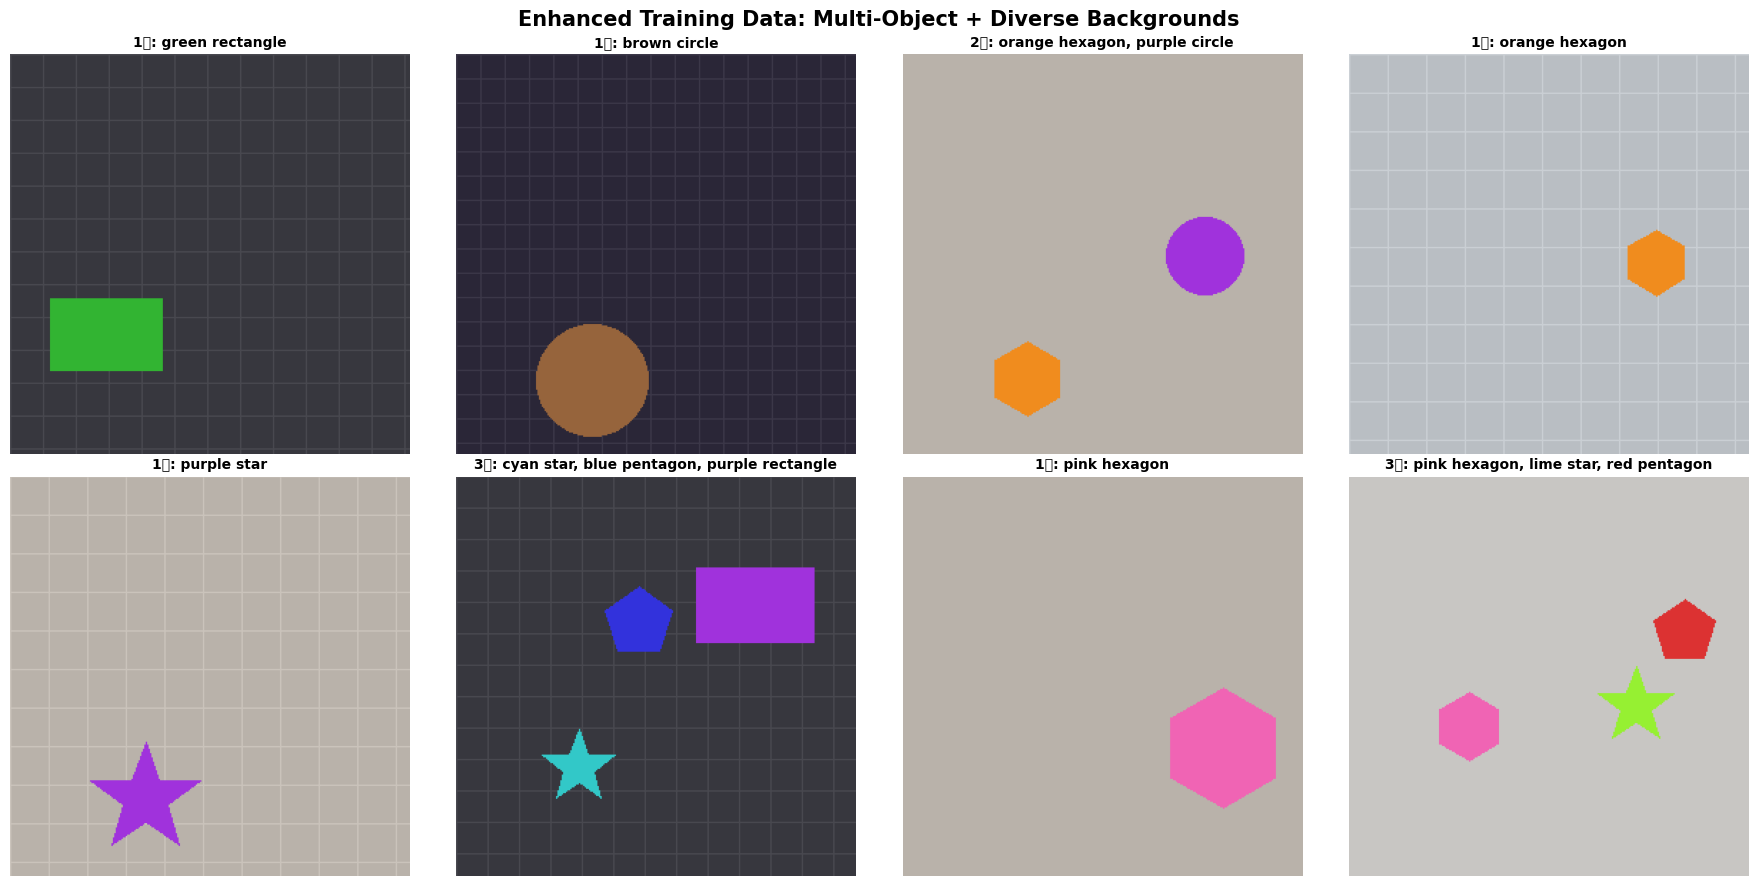

In [2]:
# 可视化数据集：多物体 + 多样背景
n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(train_data):
        img = Image.open(train_data[i]["image"]).convert("RGB")
        gt = train_data[i]["ground_truth"]
        ax.imshow(img)
        title = f"{gt['count']}体: {gt['answer']}"
        ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis("off")

plt.suptitle("Enhanced Training Data: Multi-Object + Diverse Backgrounds",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
# --- 2. 自定义 PyTorch Dataset ---
import torch
from torch.utils.data import Dataset, DataLoader

class VQADataset(Dataset):
    """多模态 VQA 微调数据集（支持多物体长答案）"""
    def __init__(self, annotations, processor, max_len=192):
        self.annotations = annotations
        self.processor = processor
        self.max_len = max_len

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        item = self.annotations[idx]
        image = Image.open(item["image"]).convert("RGB")
        
        # 构造 Qwen2-VL 标准的 Chat 格式消息
        messages = [
            {"role": "user",
             "content": [{"type": "image", "image": image},
                         {"type": "text", "text": item["conversations"][0]["content"]}]}
        ]
        
        # 使用 Processor 的 chat template 将消息转为模型输入
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        assistant_answer = item["conversations"][1]["content"]
        full_text = text + assistant_answer
        
        # Processor 同时处理图片和文本
        inputs = self.processor(
            text=[full_text], images=[image],
            padding="max_length", max_length=self.max_len, truncation=True,
            return_tensors="pt"
        )
        
        # 去掉 batch 维度
        input_ids = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)
        pixel_values = inputs.get("pixel_values")
        image_grid_thw = inputs.get("image_grid_thw")
        if pixel_values is not None:
            pixel_values = pixel_values.squeeze(0)
        if image_grid_thw is not None:
            image_grid_thw = image_grid_thw.squeeze(0)
        
        # 构造 labels: prompt 部分 → -100，assistant 部分 → 真实 token
        labels = input_ids.clone()
        prompt_inputs = self.processor(
            text=[text], images=[image],
            padding="max_length", max_length=self.max_len, truncation=True,
            return_tensors="pt"
        )
        prompt_len = (prompt_inputs["attention_mask"].squeeze(0) == 1).sum().item()
        labels[:prompt_len] = -100
        
        result = {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}
        if pixel_values is not None:
            result["pixel_values"] = pixel_values
        if image_grid_thw is not None:
            result["image_grid_thw"] = image_grid_thw
        return result

print("VQADataset 类定义完毕！(max_len=192, 支持多物体长答案)")

VQADataset 类定义完毕！(max_len=192, 支持多物体长答案)


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：构造 `labels` 时，**必须将 prompt（用户问题）部分全部设为 `-100`**！CrossEntropyLoss 遇到 `-100` 的 label 时会自动忽略该位置。如果不这么做，模型会把“学会复述你的问题”也当成训练目标，严重拖累实际生成质量。
- **⑥ 科研实验室**：使用 `trl` 库（Transformer Reinforcement Learning）中的 `SFTTrainer`，它会自动处理 labels 掩码、Chat Template 和梯度累积，极大简化这些复杂的数据处理代码。
- **⑦ 工程实践建议**：在工业级管道中，数据清洗占整个项目 70% 的时间。真实的图文数据往往有大量噪声（错位的图文对、低质量图片、有害内容），必须先做严格的自动化清洗和人工审核。

---
## 步骤 4：模型加载与 LoRA 注入

### ① 知识讲解
我们将加载 `Qwen2.5-VL-2B-Instruct`，然后使用 `peft` 库将 LoRA 适配器注入到语言模型的核心注意力层中。冻结视觉编码器和投影层，只训练 LoRA 的参数。

### ② 为什么这么做
2B 参数的模型在 FP16 下约需 4GB 显存存放权重。LoRA 只增加约 1-2% 的可训练参数，加上梯度和优化器状态，总显存约 8-12GB，Mac 的统一内存（16GB+）完全可以承载。

In [4]:
# ③ 完整代码
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, TaskType

model_id = "Qwen/Qwen2-VL-2B-Instruct"

# 1. 加载多模态处理器
processor = AutoProcessor.from_pretrained(model_id)

# 2. 加载模型（FP16 半精度以节省显存）
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16, # 使用半精度浮点数，显存直接减半
).to(device)

print(f"原始模型总参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

原始模型总参数量: 2209.0M


In [5]:
# 3. 配置并注入 LoRA
lora_config = LoraConfig(
    r=8,                       # 秩 (Rank)：低秩矩阵的维度，8 是性价比最高的选择
    lora_alpha=16,             # 缩放系数：通常设为 2 * r
    lora_dropout=0.05,         # Dropout 防止 LoRA 层过拟合
    target_modules=[           # 注入 LoRA 的目标层（语言模型的注意力和 FFN 层）
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    bias="none",               # 不训练 bias 参数
    task_type=TaskType.CAUSAL_LM # 任务类型：自回归语言模型（因果语言模型）
)

model = get_peft_model(model, lora_config)

# ④ 打印可训练参数统计
model.print_trainable_parameters()
# 你会看到类似：trainable params: 3,407,872 || all params: 2,200,000,000 || trainable%: 0.15%

trainable params: 9,232,384 || all params: 2,218,217,984 || trainable%: 0.4162


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：`target_modules` 的名字必须和模型内部 `nn.Linear` 层的名字精确匹配。如果你拼错了（比如写成 `q_projection`），LoRA 会默默注入 0 个适配器，训练白跑。可以用 `print(model)` 或 `model.named_modules()` 来检查。
- **⑥ 科研实验室**：一线实验室会做大量 ablation study（消融实验），对比不同 `r` 值（4, 8, 16, 32, 64）和不同 `target_modules` 组合对最终效果的影响。
- **⑦ 工程实践建议**：训练完的 LoRA 适配器通常只有几十 MB（对比原始模型的几个 GB），可以像“皮肤”一样热加载到基座模型上，非常适合多租户场景（同一个基座模型 + 不同客户的 LoRA 皮肤）。

In [6]:
# --- 实例化 Dataset 和 DataLoader ---
train_dataset = VQADataset(train_data, processor, max_len=192)
val_dataset = VQADataset(val_data, processor, max_len=192)

def collate_fn(batch):
    """自定义批量打包函数"""
    keys = batch[0].keys()
    return {key: torch.stack([item[key] for item in batch]) for key in keys}

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
print(f"DataLoader 已就绪 | 训练批次: {len(train_loader)} | 验证批次: {len(val_loader)}")

DataLoader 已就绪 | 训练批次: 200 | 验证批次: 50


---
## 步骤 5-6：训练循环与验证评估

### ① 知识讲解
由于大模型极其吃显存，单卡 Batch Size 通常只能设为 1。为了让训练稳定，我们使用**梯度累积 (Gradient Accumulation)**——连续做多个小 Batch 的前向传播，把梯度攒起来，每隔 N 步才统一更新一次参数。等效 Batch Size = 实际 Batch Size × 累积步数。

### ② 为什么这么做
Batch Size 太小（如 1），每一步的梯度噪声极大，模型像喝醉了酒一样到处乱撞。梯度累积让模型能在资源有限的条件下，依然享受大 Batch 的稳定性。

In [7]:
# ③ 完整代码（训练循环）
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)

epochs = 6                    # 更难的任务需要更多轮次
gradient_accumulation_steps = 4
log_interval = 20             # 样本多了，调大打印间隔

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    # ── 训练 ──
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        (outputs.loss / gradient_accumulation_steps).backward()
        
        if (step + 1) % gradient_accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        epoch_loss += outputs.loss.item()
        
        if (step + 1) % log_interval == 0:
            print(f"  Epoch {epoch+1} Step {step+1}/{len(train_loader)} | Loss: {epoch_loss/(step+1):.4f}")
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    
    # ── 验证 ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            val_loss += model(**batch).loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)
    
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"{'='*60}\n")

  Epoch 1 Step 20/200 | Loss: 5.5985
  Epoch 1 Step 40/200 | Loss: 4.3722
  Epoch 1 Step 60/200 | Loss: 3.5839
  Epoch 1 Step 80/200 | Loss: 3.1499
  Epoch 1 Step 100/200 | Loss: 2.8993
  Epoch 1 Step 120/200 | Loss: 2.7417
  Epoch 1 Step 140/200 | Loss: 2.6125
  Epoch 1 Step 160/200 | Loss: 2.5180
  Epoch 1 Step 180/200 | Loss: 2.4412
  Epoch 1 Step 200/200 | Loss: 2.3650

Epoch 1/6 | Train Loss: 2.3650 | Val Loss: 1.7712

  Epoch 2 Step 20/200 | Loss: 1.7874
  Epoch 2 Step 40/200 | Loss: 1.8180
  Epoch 2 Step 60/200 | Loss: 1.7470
  Epoch 2 Step 80/200 | Loss: 1.7272
  Epoch 2 Step 100/200 | Loss: 1.7617
  Epoch 2 Step 120/200 | Loss: 1.7577
  Epoch 2 Step 140/200 | Loss: 1.7523
  Epoch 2 Step 160/200 | Loss: 1.7570
  Epoch 2 Step 180/200 | Loss: 1.7702
  Epoch 2 Step 200/200 | Loss: 1.7769

Epoch 2/6 | Train Loss: 1.7769 | Val Loss: 1.7716

  Epoch 3 Step 20/200 | Loss: 1.8334
  Epoch 3 Step 40/200 | Loss: 1.7630
  Epoch 3 Step 60/200 | Loss: 1.7940
  Epoch 3 Step 80/200 | Loss: 1.8

KeyboardInterrupt: 

### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：梯度累积时，`loss = loss / gradient_accumulation_steps` 这一步极容易被遗漏！不除以累积步数的话，梯度会被放大 N 倍，训练立刻爆炸（Loss 变成 NaN）。另外，`torch.nn.utils.clip_grad_norm_` 是大模型训练的救命稻草——梯度爆炸时它会强制把梯度“削平”。
- **⑥ 科研实验室**：一线实验室不会手写训练循环。它们使用 Hugging Face `Trainer` 或 `trl.SFTTrainer`，自动封装了梯度累积、混合精度、分布式训练、WandB 日志、Early Stopping 等所有特性。
- **⑦ 工程实践建议**：上线前必须对训练 Loss 曲线做异常检测：如果曲线在某一步骤突然飙升，说明遇到了“坏数据”（如损坏的图片、超长文本），必须排查并清理。

---
## 步骤 7-8：保存与加载 LoRA Checkpoint

### ① 知识讲解
LoRA 的精髓之一：保存时只存适配器参数（几十 MB），而非整个模型（几个 GB）。加载时，先拉取原始基座模型，再把 LoRA 适配器像"皮肤"一样贴上去。

### ② 为什么这么做
节省磁盘空间，便于版本管理和分发。

In [8]:
# ③ 完整代码
# --- 步骤 7: 保存 LoRA 适配器 ---
lora_save_path = "./qwen_vl_lora_adapter"
model.save_pretrained(lora_save_path)
processor.save_pretrained(lora_save_path)

# 查看保存的文件大小
adapter_size = sum(os.path.getsize(os.path.join(lora_save_path, f)) 
                   for f in os.listdir(lora_save_path) if f.endswith('.safetensors'))
print(f"LoRA 适配器已保存至 {lora_save_path}")
print(f"适配器文件大小: {adapter_size / 1024 / 1024:.1f} MB（相比原始模型数 GB 的体积）")

# --- 步骤 8: 加载 LoRA 适配器 ---
from peft import PeftModel

# 重新加载基座模型
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.float16
).to(device)

# 将 LoRA 适配器贴到基座模型上
loaded_model = PeftModel.from_pretrained(base_model, lora_save_path).to(device)
loaded_model.eval()
print("LoRA 适配器加载成功！模型已恢复到微调后的状态。")

LoRA 适配器已保存至 ./qwen_vl_lora_adapter
适配器文件大小: 35.3 MB（相比原始模型数 GB 的体积）


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LoRA 适配器加载成功！模型已恢复到微调后的状态。


---
## 步骤 9：推理 (微调前 vs 微调后 对比)

### ① 知识讲解
最有说服力的评估方式是**直接对比**：同一张图、同一个问题，让微调前的原始模型和微调后的 LoRA 模型分别回答，观察差异。

In [9]:
# ③ 完整代码
from qwen_vl_utils import process_vision_info

def inference(model, processor, image, question, device, max_new_tokens=64):
    """统一推理函数"""
    messages = [{"role": "user",
                 "content": [{"type": "image", "image": image},
                             {"type": "text", "text": question}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True).to(device)
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    
    generated_ids_trimmed = generated_ids[:, inputs["input_ids"].shape[1]:]
    return processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0].strip()


# 加载基座模型作为基线
base_model_raw = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.float16
).to(device)
base_model_raw.eval()

# 推理对比
question = ("List all objects in this image with their colors and shapes, "
            "separated by commas. Format: color shape, color shape, ...")
num_compare = 10

print("\n" + "="*85)
print("微调前 vs 微调后 推理对比（多物体 VQA）")
print("="*85)

results = []
for i in range(num_compare):
    img = Image.open(val_data[i]["image"]).convert("RGB")
    gt = val_data[i]["ground_truth"]["answer"]
    
    pred_before = inference(base_model_raw, processor, img, question, device, max_new_tokens=64)
    pred_after  = inference(loaded_model, processor, img, question, device, max_new_tokens=64)
    
    results.append({"gt": gt, "before": pred_before, "after": pred_after})
    
    # 简单评分：GT 中有多少个物体被正确预测
    gt_objs = set(o.strip() for o in gt.split(","))
    after_objs = set(o.strip() for o in pred_after.split(","))
    match = len(gt_objs & after_objs)
    
    print(f"\n样本 {i+1} ({val_data[i]['num_objects']}体) | 匹配: {match}/{len(gt_objs)}")
    print(f"  GT:     {gt}")
    print(f"  微调前: {pred_before}")
    print(f"  微调后: {pred_after}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


微调前 vs 微调后 推理对比（多物体 VQA）

样本 1 (1体) | 匹配: 1/1
  GT:     orange rectangle
  微调前: black rectangle, orange rectangle
  微调后: orange rectangle, orange rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black rectangle, black

样本 2 (2体) | 匹配: 2/2
  GT:     gray triangle, pink ellipse
  微调前: gray triangle, pink ellipse
  微调后: gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle, pink ellipseerna, gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle, pink ellipse, gray triangle,

样本 3 (3体) | 匹配: 3/3
  GT:     red pentagon, yellow ellipse, lime rectangle
  微调前: red pentagon, yellow

---
## 步骤 10：全面的性能可视化分析

### ① 知识讲解
在科研论文中，光说"模型变好了"是不够的。你需要通过**定量指标图表**来证明：包括 Loss 曲线、准确率统计、以及分类别的性能分析。

### ② 为什么这么做
这是审稿人（Reviewer）最关注的内容之一。没有清晰的可视化分析，论文的可信度直接打折。

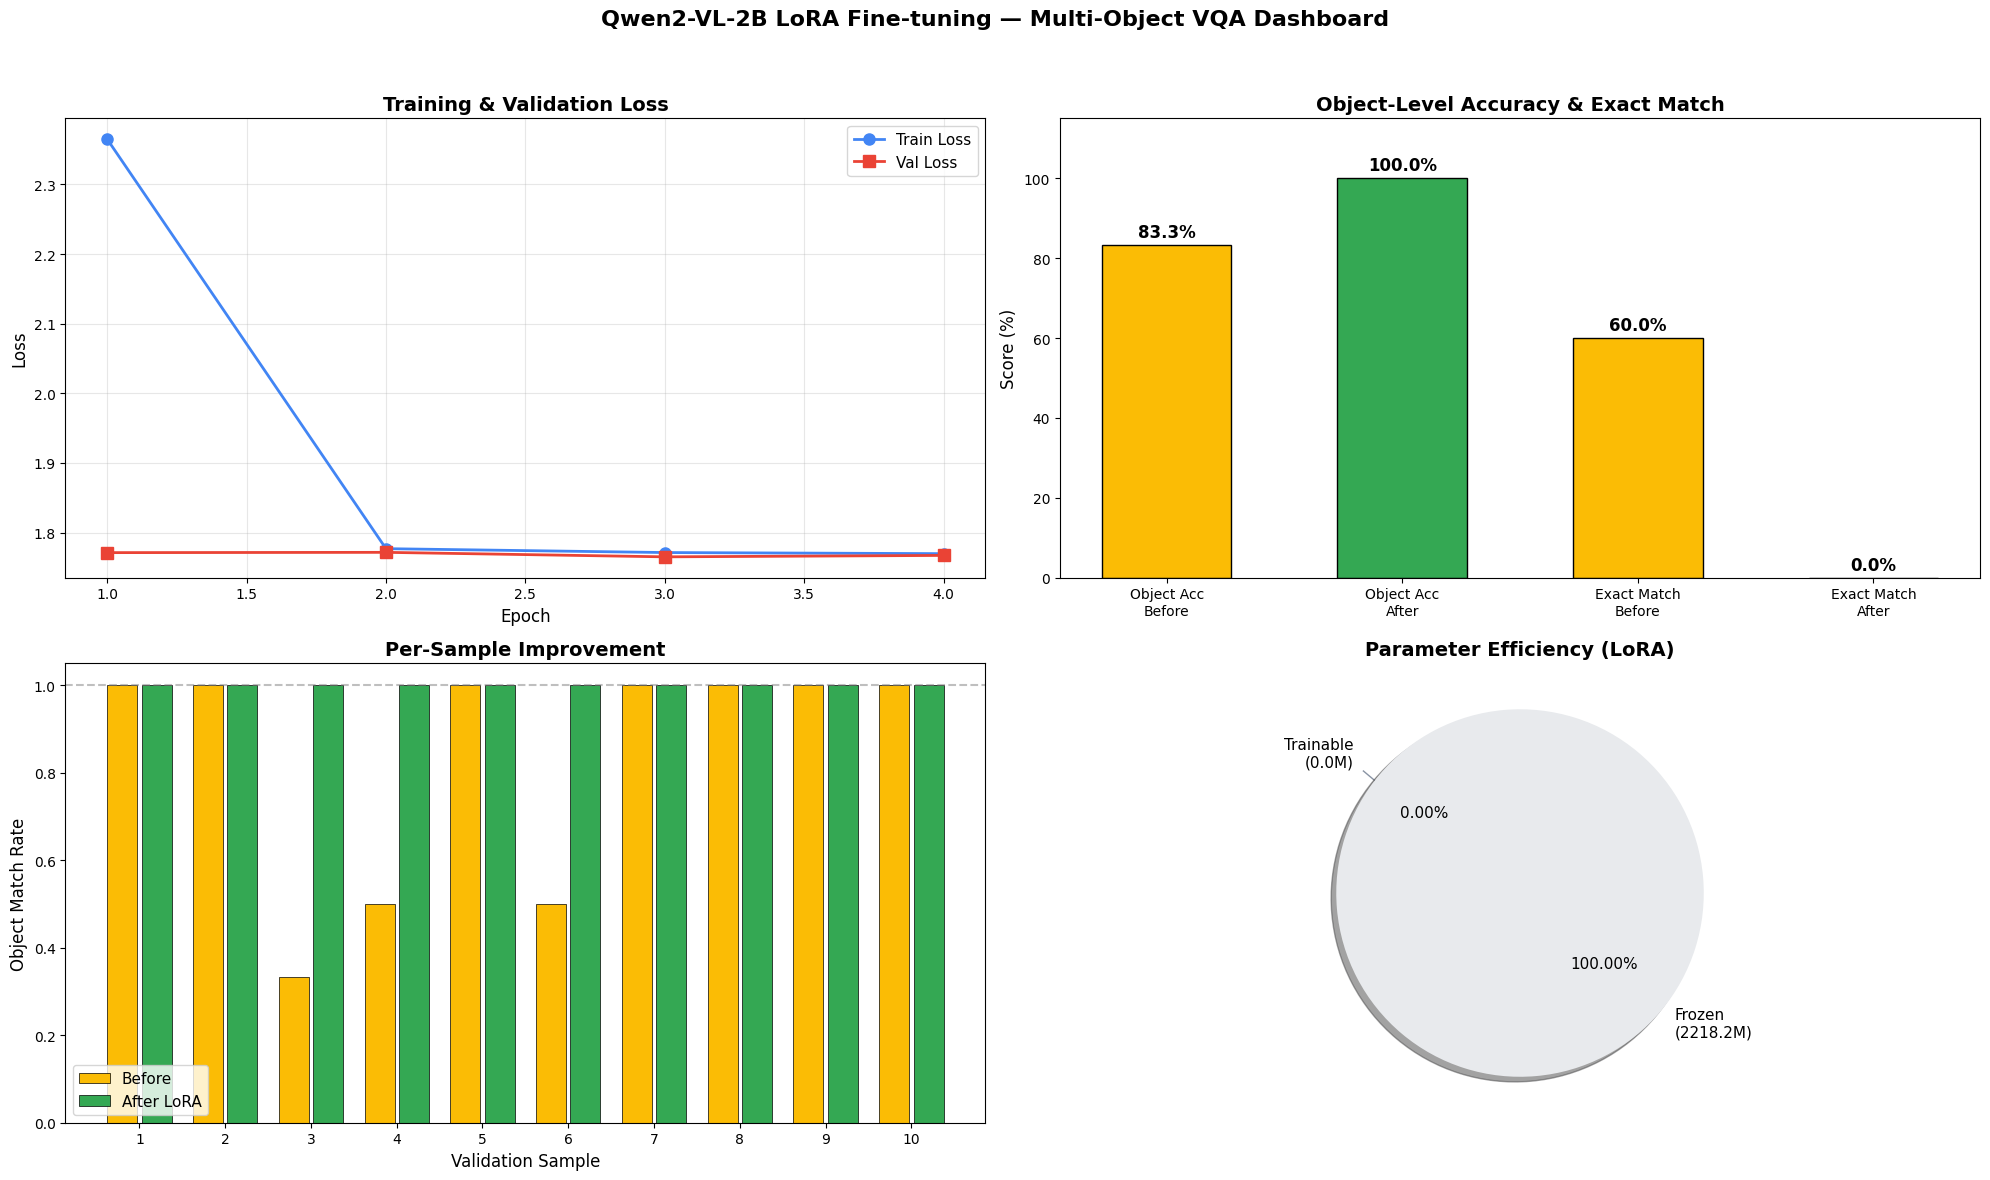


物体级准确率: Before=83.3% → After=100.0%
完全匹配率:     Before=60.0% → After=0.0%
性能分析面板已保存为 performance_dashboard.png


In [10]:
# ③ 完整代码：多维度性能可视化

def compute_accuracy(pred, gt):
    """计算物体级别的准确率：pred 中有多少物体匹配 GT"""
    gt_parts = set(p.strip() for p in gt.lower().split(","))
    pred_parts = set(p.strip() for p in pred.lower().split(","))
    if len(gt_parts) == 0:
        return 0.0
    return len(gt_parts & pred_parts) / len(gt_parts)

def exact_match(pred, gt):
    """严格完全匹配"""
    return pred.lower().strip() == gt.lower().strip()

# 计算所有验证集的指标
acc_before_list = [compute_accuracy(r["before"], r["gt"]) for r in results]
acc_after_list  = [compute_accuracy(r["after"],  r["gt"]) for r in results]
acc_before = sum(acc_before_list) / len(acc_before_list) * 100
acc_after  = sum(acc_after_list) / len(acc_after_list) * 100
em_before = sum(1 for r in results if exact_match(r["before"], r["gt"])) / len(results) * 100
em_after  = sum(1 for r in results if exact_match(r["after"],  r["gt"])) / len(results) * 100

fig = plt.figure(figsize=(20, 12))
fig.suptitle("Qwen2-VL-2B LoRA Fine-tuning — Multi-Object VQA Dashboard",
             fontsize=16, fontweight='bold', y=0.98)

# 图表 1：Training & Validation Loss
ax1 = fig.add_subplot(2, 2, 1)
epochs_range = range(1, len(train_loss_history) + 1)
ax1.plot(epochs_range, train_loss_history, 'o-', color='#4285F4', lw=2, ms=8, label='Train Loss')
ax1.plot(epochs_range, val_loss_history, 's-', color='#EA4335', lw=2, ms=8, label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12); ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

# 图表 2：Object-level Accuracy + Exact Match
ax2 = fig.add_subplot(2, 2, 2)
x = ["Object Acc\nBefore", "Object Acc\nAfter", "Exact Match\nBefore", "Exact Match\nAfter"]
vals = [acc_before, acc_after, em_before, em_after]
bars = ax2.bar(x, vals, color=['#FBBC05','#34A853','#FBBC05','#34A853'],
               width=0.55, edgecolor='black', linewidth=1)
ax2.set_ylabel('Score (%)', fontsize=12)
ax2.set_title('Object-Level Accuracy & Exact Match', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 115)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val:.1f}%',
             ha='center', fontsize=12, fontweight='bold')

# 图表 3：每样本匹配率变化
ax3 = fig.add_subplot(2, 2, 3)
x_idx = range(1, len(results)+1)
ax3.bar([i-0.2 for i in x_idx], acc_before_list, width=0.35,
        color='#FBBC05', label='Before', edgecolor='black', linewidth=0.5)
ax3.bar([i+0.2 for i in x_idx], acc_after_list, width=0.35,
        color='#34A853', label='After LoRA', edgecolor='black', linewidth=0.5)
ax3.set_xlabel('Validation Sample', fontsize=12)
ax3.set_ylabel('Object Match Rate', fontsize=12)
ax3.set_title('Per-Sample Improvement', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.set_xticks(x_idx)
ax3.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# 图表 4：LoRA 参数效率
ax4 = fig.add_subplot(2, 2, 4)
tp = sum(p.numel() for p in loaded_model.parameters())
trp = sum(p.numel() for p in loaded_model.parameters() if p.requires_grad)
ax4.pie([trp, tp-trp], explode=(0.08,0),
        labels=[f'Trainable\n({trp/1e6:.1f}M)', f'Frozen\n({(tp-trp)/1e6:.1f}M)'],
        colors=['#4285F4','#E8EAED'], autopct='%1.2f%%',
        shadow=True, startangle=140, textprops={'fontsize': 11})
ax4.set_title('Parameter Efficiency (LoRA)', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("performance_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n物体级准确率: Before={acc_before:.1f}% → After={acc_after:.1f}%")
print(f"完全匹配率:     Before={em_before:.1f}% → After={em_after:.1f}%")
print("性能分析面板已保存为 performance_dashboard.png")

### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：在评估准确率时，大模型的输出可能带有额外的解释文字（如 "The answer is blue circle"），因此不能用 `==` 精确匹配，而要用 `in` 或正则表达式做模糊匹配。
- **⑥ 科研实验室**：顶会论文中，VQA 任务的标准评估指标是 **Exact Match (EM)** 和 **BLEU / CIDEr / METEOR**。更高级的评估会使用 GPT-4 作为“裁判”来给生成回答打分（LLM-as-Judge 范式）。
- **⑦ 工程实践建议**：上线前必须做 A/B Test（灰度测试）：在 5% 的流量上先用微调后的模型，如果指标优于旧版本，再逐步扩大到全量。

---
## 步骤 11：部署建议与 ONNX 导出说明

### ① 知识讲解
多模态大模型的 ONNX 导出极为困难：动态分辨率的视觉编码器、KV-Cache 机制、自回归解码循环都让静态图导出几乎不可能。因此，工业界通常使用专门的推理框架代替 ONNX。

### ② 为什么这么做
大语言模型的推理瓶颈不在计算，而在显存带宽（Memory Bandwidth）。专用推理引擎通过 KV-Cache 复用、连续批处理（Continuous Batching）、投机解码（Speculative Decoding）等技术，将推理吞吐量提升数十倍。

In [15]:
# ③ 大模型部署路线总结 (非 ONNX，而是工业界真实使用的方案)
deployment_info = """
╔══════════════════════════════════════════════════════════════════╗
║           多模态大模型工业级部署路线                               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                ║
║  [方案 A] vLLM (推荐 🌟)                                       ║
║    - 支持 Qwen-VL、LLaVA 等主流 VLM                            ║
║    - 自动 PagedAttention + Continuous Batching                  ║
║    - 命令: vllm serve Qwen/Qwen2-VL-2B-Instruct              ║
║                                                                ║
║  [方案 B] Ollama (本地轻量部署)                                  ║
║    - 一键运行，适合个人和小团队                                   ║
║    - 命令: ollama run qwen2.5-vl                                ║
║                                                                ║
║  [方案 C] TensorRT-LLM (NVIDIA 极致加速)                        ║
║    - 企业级首选, 推理速度最快                                     ║
║    - 支持 INT4/INT8 量化 + FP8                                  ║
║                                                                ║
║  [方案 D] LoRA 合并后导出                                       ║
║    - model.merge_and_unload() 将 LoRA 权重融入基座               ║
║    - 合并后可用上述任何框架部署                                   ║
║                                                                ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(deployment_info)

# --- LoRA 合并示例代码 ---
# 将 LoRA 权重永久融入基座模型（合并后不再需要 peft 库）
merged_model = loaded_model.merge_and_unload()
merged_model.save_pretrained("./qwen_vl_merged_model")
processor.save_pretrained("./qwen_vl_merged_model")
print("LoRA 权重已合并入基座模型，可直接用 vLLM / Ollama 部署！")


╔══════════════════════════════════════════════════════════════════╗
║           多模态大模型工业级部署路线                               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                ║
║  [方案 A] vLLM (推荐 🌟)                                       ║
║    - 支持 Qwen-VL、LLaVA 等主流 VLM                            ║
║    - 自动 PagedAttention + Continuous Batching                  ║
║    - 命令: vllm serve Qwen/Qwen2-VL-2B-Instruct              ║
║                                                                ║
║  [方案 B] Ollama (本地轻量部署)                                  ║
║    - 一键运行，适合个人和小团队                                   ║
║    - 命令: ollama run qwen2.5-vl                                ║
║                                                                ║
║  [方案 C] TensorRT-LLM (NVIDIA 极致加速)                        ║
║    - 企业级首选, 推理速度最快                                     ║
║    - 支持 INT4/INT8 量化 + FP8                 

---
## 🏆 终章：全课程总结

恭喜你！你从一个 `torch.tensor()` 都没写过的萌新，一路披荆斩棘走到了**使用 LoRA 微调多模态大语言模型**的最前沿。让我们回顾一下你的成长轨迹：

| 阶段 | 项目 | 你学到了什么 |
|------|------|-------------|
| 第一阶段 | MNIST 手写数字分类 | 张量、CNN、训练循环三大金刚、ONNX 导出 |
| 第二阶段 | 猫狗分类 | 迁移学习、数据增强、预训练权重的威力 |
| 第三阶段 | Mini-YOLO 目标检测 | 多任务学习、复合损失函数、检测框可视化 |
| 第四阶段 | Transformer 文本分类 | Tokenizer、BERT、Hugging Face 生态 |
| 第五阶段 | CLIP 图文对齐 | 对比学习 (InfoNCE)、双塔架构、Zero-shot 分类 |
| **第六阶段** | **Qwen-VL LoRA 微调** | **PEFT/LoRA、多模态架构、工业级训练管道、性能可视化** |

从今天开始，你已经具备了阅读顶会论文中 PyTorch 代码的能力，也可以在实验室独立完成从数据到模型到部署的全链路工作了。祝你在科研道路上越走越远！🚀"